In [ ]:
import pandas as pd


In [41]:
df.to_csv(
    "D:\\Project\\InfluenceGuard-AI\\data\\processed_influencers.csv",
    index=False
)

In [3]:
df = pd.read_csv("D:\Project\InfluenceGuard-AI\data\influencers.csv")

In [4]:
df.head()

,Name,Rank,Category,Followers,Audience Country,Authentic Engagement,Engagement Avg.
0,cristiano,1,Sports with a ball,462.9M,India,5.5M,6.6M
1,leomessi,2,Sports with a ballFamily,347.2M,Argentina,3.6M,4.8M
2,kendalljenner,3,ModelingFashion,247.6M,United States,3M,4.9M
3,arianagrande,4,Music,321.4M,United States,2.4M,3.4M
4,zendaya,5,Cinema & Actors/actressesFashion,147M,United States,4.3M,5.8M


In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 7 columns):
 #   Column                Non-Null Count  Dtype 
---  ------                --------------  ----- 
 0   Name                  1000 non-null   object
 1   Rank                  1000 non-null   int64 
 2   Category              916 non-null    object
 3   Followers             1000 non-null   object
 4   Audience Country      986 non-null    object
 5   Authentic Engagement  1000 non-null   object
 6   Engagement Avg.       1000 non-null   object
dtypes: int64(1), object(6)
memory usage: 54.8+ KB


In [6]:
df.isnull().sum()

Name                     0
Rank                     0
Category                84
Followers                0
Audience Country        14
Authentic Engagement     0
Engagement Avg.          0
dtype: int64

In [7]:
df.describe()

,Rank
count,1000.000000
mean,500.500000
std,288.819436
min,1.000000
25%,250.750000
50%,500.500000
75%,750.250000
max,1000.000000


In [8]:
# covert string to numeric
def convert_to_number(value):

    value = str(value).replace(",", "").strip()

    if "M" in value:
        return float(value.replace("M", "")) * 1_000_000

    elif "K" in value:
        return float(value.replace("K", "")) * 1_000

    else:
        try:
            return float(value)
        except:
            return None

In [9]:
df["Followers"] = df["Followers"].apply(convert_to_number)

df["Authentic Engagement"] = df["Authentic Engagement"].apply(convert_to_number)

df["Engagement Avg."] = df["Engagement Avg."].apply(convert_to_number)

In [10]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 7 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   Name                  1000 non-null   object 
 1   Rank                  1000 non-null   int64  
 2   Category              916 non-null    object 
 3   Followers             1000 non-null   float64
 4   Audience Country      986 non-null    object 
 5   Authentic Engagement  1000 non-null   float64
 6   Engagement Avg.       1000 non-null   float64
dtypes: float64(3), int64(1), object(3)
memory usage: 54.8+ KB


In [11]:
df.head()

,Name,Rank,Category,Followers,Audience Country,Authentic Engagement,Engagement Avg.
0,cristiano,1,Sports with a ball,462900000.0,India,5500000.0,6600000.0
1,leomessi,2,Sports with a ballFamily,347200000.0,Argentina,3600000.0,4800000.0
2,kendalljenner,3,ModelingFashion,247600000.0,United States,3000000.0,4900000.0
3,arianagrande,4,Music,321400000.0,United States,2400000.0,3400000.0
4,zendaya,5,Cinema & Actors/actressesFashion,147000000.0,United States,4300000.0,5800000.0


In [12]:
# fill missing values
df["Category"] = df["Category"].fillna("Unknown")

df["Audience Country"] = df["Audience Country"].fillna("Unknown")

In [13]:
df.isnull().sum()

Name                    0
Rank                    0
Category                0
Followers               0
Audience Country        0
Authentic Engagement    0
Engagement Avg.         0
dtype: int64

In [14]:
# Engagement rate
df["Engagement Rate"] = (df["Authentic Engagement"] / df["Followers"]) * 100

In [15]:
df.head()

,Name,Rank,Category,Followers,Audience Country,Authentic Engagement,Engagement Avg.,Engagement Rate
0,cristiano,1,Sports with a ball,462900000.0,India,5500000.0,6600000.0,1.188162
1,leomessi,2,Sports with a ballFamily,347200000.0,Argentina,3600000.0,4800000.0,1.036866
2,kendalljenner,3,ModelingFashion,247600000.0,United States,3000000.0,4900000.0,1.211632
3,arianagrande,4,Music,321400000.0,United States,2400000.0,3400000.0,0.746733
4,zendaya,5,Cinema & Actors/actressesFashion,147000000.0,United States,4300000.0,5800000.0,2.925170


In [16]:
# Fake Influencer Score
def fake_score(row):

    score = 0

    if row["Engagement Rate"] < 1:
        score += 50

    if row["Followers"] > 100000000 and row["Authentic Engagement"] < 1000000:
        score += 30

    return score

In [17]:
df["Fake Score"] = df.apply(fake_score, axis=1)

In [18]:
df.head()

,Name,Rank,Category,Followers,Audience Country,Authentic Engagement,Engagement Avg.,Engagement Rate,Fake Score
0,cristiano,1,Sports with a ball,462900000.0,India,5500000.0,6600000.0,1.188162,0
1,leomessi,2,Sports with a ballFamily,347200000.0,Argentina,3600000.0,4800000.0,1.036866,0
2,kendalljenner,3,ModelingFashion,247600000.0,United States,3000000.0,4900000.0,1.211632,0
3,arianagrande,4,Music,321400000.0,United States,2400000.0,3400000.0,0.746733,50
4,zendaya,5,Cinema & Actors/actressesFashion,147000000.0,United States,4300000.0,5800000.0,2.925170,0


In [19]:
df

,Name,Rank,Category,Followers,Audience Country,Authentic Engagement,Engagement Avg.,Engagement Rate,Fake Score
0,cristiano,1,Sports with a ball,462900000.0,India,5500000.0,6600000.0,1.188162,0
1,leomessi,2,Sports with a ballFamily,347200000.0,Argentina,3600000.0,4800000.0,1.036866,0
2,kendalljenner,3,ModelingFashion,247600000.0,United States,3000000.0,4900000.0,1.211632,0
3,arianagrande,4,Music,321400000.0,United States,2400000.0,3400000.0,0.746733,50
4,zendaya,5,Cinema & Actors/actressesFashion,147000000.0,United States,4300000.0,5800000.0,2.925170,0
...,...,...,...,...,...,...,...,...,...
995,nimratkhairaofficial,996,Music,8000000.0,India,211100.0,261800.0,2.638750,0
996,hanhyojoo222,997,TravelCinema & Actors/actresses,4000000.0,Indonesia,434200.0,518200.0,10.855000,0
997,memphisdepay,998,Sports with a ball,15000000.0,France,76400.0,135500.0,0.509333,50
998,arminzareeiofficial,999,Unknown,9800000.0,Iran,135400.0,214000.0,1.381633,0


In [20]:
# trust score
df["Trust Score"] = 100 - df["Fake Score"]

In [21]:
df.head()

,Name,Rank,Category,Followers,Audience Country,Authentic Engagement,Engagement Avg.,Engagement Rate,Fake Score,Trust Score
0,cristiano,1,Sports with a ball,462900000.0,India,5500000.0,6600000.0,1.188162,0,100
1,leomessi,2,Sports with a ballFamily,347200000.0,Argentina,3600000.0,4800000.0,1.036866,0,100
2,kendalljenner,3,ModelingFashion,247600000.0,United States,3000000.0,4900000.0,1.211632,0,100
3,arianagrande,4,Music,321400000.0,United States,2400000.0,3400000.0,0.746733,50,50
4,zendaya,5,Cinema & Actors/actressesFashion,147000000.0,United States,4300000.0,5800000.0,2.925170,0,100


In [22]:
# visualization
import plotly.express as px

In [23]:
top_10 = df.nlargest(10, "Followers")

fig = px.bar(
    top_10,
    x="Name",
    y="Followers",
    color="Trust Score",
    title="Top 10 Influencers by Followers",
)

fig.show()

In [24]:
suspicious = df.sort_values(by="Fake Score", ascending=False).head(10)

fig = px.bar(
    suspicious,
    x="Name",
    y="Engagement Rate",
    color="Fake Score",
    hover_data=["Followers", "Authentic Engagement", "Trust Score"],
    title="Low Engagement Influencers With High Fake Score",
)

fig.show()

In [25]:
suspicious = df.sample(10)

fig = px.bar(
    suspicious,
    x="Name",
    y="Engagement Rate",
    color="Fake Score",
    text="Trust Score",
    hover_data=["Followers", "Authentic Engagement"],
    title="Random Influencer Engagement Analysis",
)

fig.update_traces(textposition="outside")

fig.show()

In [26]:
# country by influencers anylysis
country_data = df["Audience Country"].value_counts().head(10).reset_index()

country_data.columns = ["Country", "Influencers Count"]

In [27]:
fig = px.bar(
    country_data,
    x="Country",
    y="Influencers Count",
    color="Influencers Count",
    title="Top Countries By Influencer Count",
)

fig.show()

In [28]:
# category by influencers analysis
category_data = df["Category"].value_counts().head(10).reset_index()

category_data.columns = ["Category", "Influencers Count"]

In [29]:
fig = px.pie(
    category_data,
    names="Category",
    values="Influencers Count",
    title="Top Influencer Categories",
)

fig.show()

In [30]:
# correlation heatmap
numeric_df = df.select_dtypes(include=["float64", "int64"])

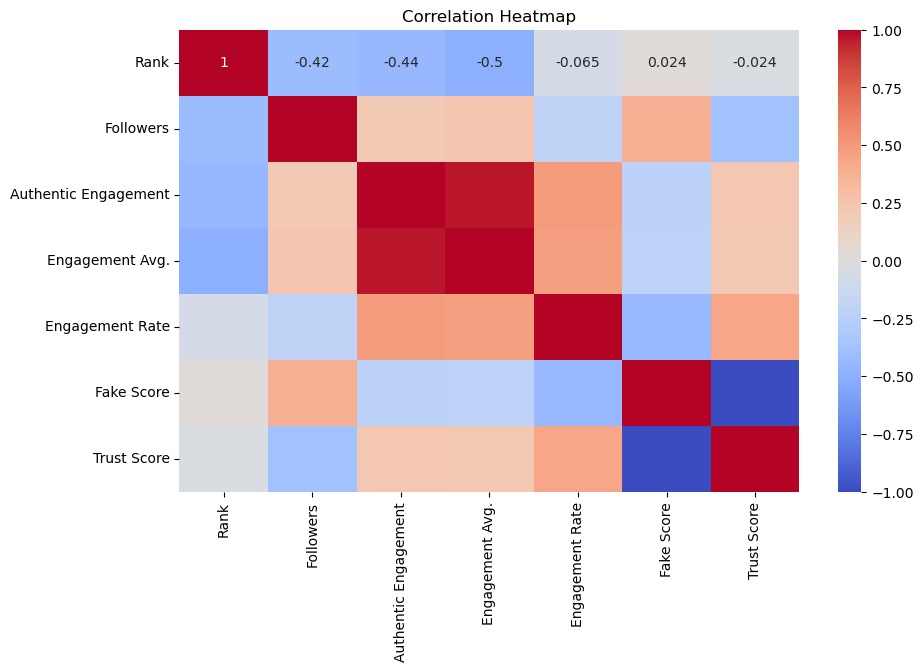

In [31]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 6))

sns.heatmap(numeric_df.corr(), annot=True, cmap="coolwarm")

plt.title("Correlation Heatmap")

plt.show()

In [32]:
features = [
    'Followers',
    'Authentic Engagement',
    'Engagement Avg.',
    'Engagement Rate'
]

X = df[features]

In [ ]:
# isolatated  forest 
from sklearn.ensemble import IsolationForest

In [34]:
model = IsolationForest(
    contamination=0.05,
    random_state=42
)

df['Anomaly'] = model.fit_predict(X)

In [39]:
df[['Name', 'Engagement Rate', 'Anomaly']]


,Name,Engagement Rate,Anomaly
0,cristiano,1.188162,-1
1,leomessi,1.036866,-1
2,kendalljenner,1.211632,-1
3,arianagrande,0.746733,-1
4,zendaya,2.925170,-1
...,...,...,...
995,nimratkhairaofficial,2.638750,1
996,hanhyojoo222,10.855000,1
997,memphisdepay,0.509333,1
998,arminzareeiofficial,1.381633,1


In [40]:
fig = px.scatter(
    df,
    x='Followers',
    y='Engagement Rate',
    color='Anomaly',
    hover_data=['Name'],
    title='Anomaly Detection Of Influencers'
)

fig.show()